### Analisis y procesamiento de señales - UNSAM <img src=./logo_UNSAM.jpg align = right width = 150>
## TS5: Estimación espectral: Ancho de banda de señales reales
### Jeronimo Lanzavechia

Aclaracion: El formateo de los gráficos y las porciones del documento en Latex se hicieron con Chat-GPT

## Introducción

En situaciones del mundo real, es de interes poder estimar el espectro de señales y donde esta contenida la mayoria de la información, a modo de poder descartar, bajo cierto criterio, aquello que no es importante. En estas situaciones, solo se tendría noción del tipo de señal y su espectro, pero nada exacto. 
En el trabajo anterior, se vió como con ventanas era posible apreciar ciertas partes de una señal, obteniendo mayor o menor sesgo o varianza, pero el método que se empleaba para realizar la estimación seguía siendo con la transformada discreta de fourier.
La transformada discreta de fourier, empleada para estimar un espectro, crea un periodograma. Siendo el periodograma un estimador, es de interes ver su sesgo y varianza.
El sesgo y varianza del periodograma:

\begin{aligned}

\end{aligned}

Se ve que la varianza de este metodo es de segundo orden (cuarto orden para la desviación), extremadamente alta sin importar la señal a estudiar. Diferencias con el sesgo pueden solucionarse con calibración de la implementación u algoritmo, pero la varianza no tiene la misma característica. Esto le da al periodograma la cualidad de ser inconsistente. 
A partir de esto, surgen distintos metodos de estimación espectral, que buscan reducir la varianza de la estimación, sacrificando el bajo sesgo del periodograma.
El periodograma de welch tiene como mejoras la partición de los datos del espectro en bloques (traida del periodograma modificado, asumiendo que las señales a estudiar son ergódicas) y promediando la cantidad de bloques, junto con una superposición de hasta el 50% al momento de calcular la densidad de potencias.

El periodograma de welch:

\begin{aligned}
    \quad & P_{\text{Welch}}(f) = \frac{1}{K} \sum_{m=0}^{K-1} P_m(f)
\end{aligned}

Con el periodograma modificado:

\begin{aligned}
    \quad & P_m(f) = \frac{1}{LU} \left| \sum_{n=0}^{L-1} x_m(n) e^{-j 2 \pi f n} \right|^2 \\
\end{aligned}

Su varianza (50% de solapamiento):

\begin{aligned}
\quad & \text{Var}\left\{ P_{\text{Welch}}(f) \right\} \approx \frac{9}{16K} P_x^2(f)
\end{aligned}

Se reduce notablemente la varianza con respecto al metodo de estimación usado hasta el momento. Con la implementación dada por la libreria Scipy, se buscará determinar el espectro de multiples señales del mundo real, y calcular sus ancho de banda.

## Desarrollo

In [2]:
def plot_db_welch(subplot, data, fs, n, K, P, BW, VAR):
    """
    Para que el código quede más legible, armo esta funcion que plotea la
    funcion que le paso por welch usando siempre la misma configuración
    """
    L = n/K
    ffs,DSP = scps.welch(x = data,fs = fs,window = 'hann_periodic',nperseg=L)
    DSP_dB = 10*np.log(DSP/ np.max(DSP))
    subplot.plot(ffs,DSP_dB, label = f"L = {L:.2f}")
    
    potencia = 0
    potencia_total = np.sum(DSP)
    
    for i in range(n):
        if (potencia > (potencia_total*P)):
            break
        potencia = potencia + DSP[i]
        BW[0] = i*(fs*K/n)
    VAR[0] = np.var(DSP)
    
    L2 = n*(1/(10*K))
    ffs,DSP = scps.welch(x = data,fs = fs,window = 'hann_periodic',nperseg=L2)
    DSP_dB = 10*np.log(DSP / np.max(DSP))
    subplot.plot(ffs,DSP_dB, label = f"L = {L2:.2f}")

    ##estimador de ancho de banda
    potencia = 0
    potencia_total = np.sum(DSP)
           
    for i in range(n):
        if (potencia > (potencia_total*P)):
            break
        potencia = potencia + DSP[i]
        BW[1] = i*(fs*10*K/n)
    VAR[1] = np.var(DSP)

    L3 = n*(1/(100*K))
    ffs,DSP = scps.welch(x = data,fs = fs,window = 'hann_periodic',nperseg=L3)
    DSP_dB = 10*np.log(DSP / np.max(DSP))
    subplot.plot(ffs,DSP_dB, label = f"L = {L3:.2f}")
    subplot.legend()
    
    potencia = 0
    potencia_total = np.sum(DSP)
    
    for i in range(n):
        if (potencia > (potencia_total*P)):
            break
        potencia = potencia + DSP[i]
        BW[2] = i*(fs*100*K/n)
    VAR[2] = np.var(DSP)

import numpy as np
import matplotlib.pyplot as plt

### Señales de audio

In [3]:
##Señales de audio
import scipy.signal as scps
import scipy.io as sio

#### Señales

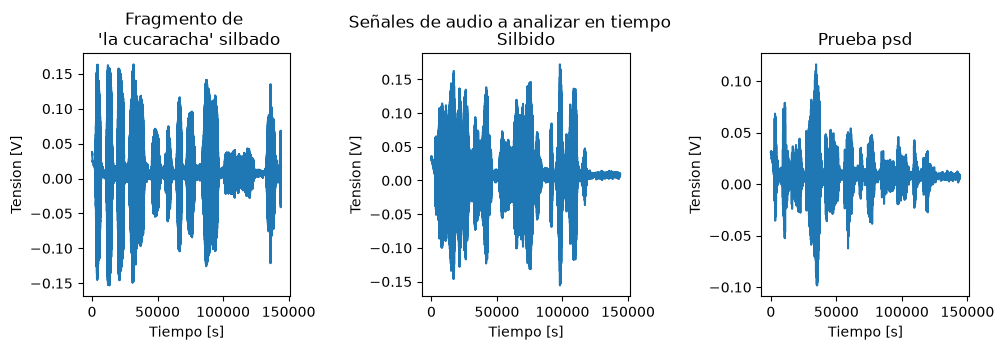

In [4]:
##graficos en tiempo
fig_audios_t, ((cucaracha_t, silbido_t, psd_t)) = plt.subplots(1,3)
fig_audios_t.suptitle("Señales de audio a analizar en tiempo",y =1.02)
fig_audios_t.tight_layout(w_pad = 3)
fig_audios_t.set_size_inches(10,3)

cucaracha_t.set_title("Fragmento de \n 'la cucaracha' silbado")
cucaracha_t.set_xlabel("Tiempo [s]")
cucaracha_t.set_ylabel("Tension [V]")

fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
cucaracha_t.plot(wav_data)

silbido_t.set_title("Silbido")
silbido_t.set_xlabel("Tiempo [s]")
silbido_t.set_ylabel("Tension [V]")

fs_audio, wav_data = sio.wavfile.read('silbido.wav')
silbido_t.plot(wav_data)

psd_t.set_title("Prueba psd")
psd_t.set_xlabel("Tiempo [s]")
psd_t.set_ylabel("Tension [V]")

fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
psd_t.plot(wav_data)


#### Estimaciones

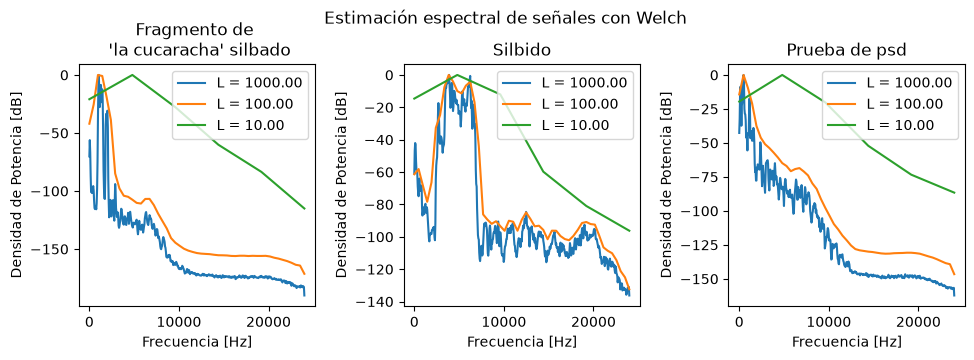

In [10]:
##graficos en frecuencia
fig_audios, ((cucaracha, silbido, psd)) = plt.subplots(1,3)
fig_audios.suptitle("Estimación espectral de señales con Welch",y =1.07)
fig_audios.tight_layout(w_pad = 1)
fig_audios.set_size_inches(10,3)
###para el grafico de tiempo

cucaracha.set_title("Fragmento de \n 'la cucaracha' silbado")
cucaracha.set_xlabel("Frecuencia [Hz]")
cucaracha.set_ylabel("Densidad de Potencia [dB]")

BW_cucaracha = [0,0,0]
VAR_cucaracha = [0,0,0]
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
plot_db_welch(cucaracha, wav_data, fs_audio, np.size(wav_data),144,0.95,BW_cucaracha,VAR_cucaracha)

psd.set_title("Prueba de psd")
psd.set_xlabel("Frecuencia [Hz]")
psd.set_ylabel("Densidad de Potencia [dB]")

VAR_prueba = [0,0,0]
BW_prueba = [0,0,0]
fs_audio, wav_data = sio.wavfile.read('prueba psd.wav')
plot_db_welch(psd, wav_data, fs_audio, np.size(wav_data),144,0.95,BW_prueba,VAR_prueba)

silbido.set_title("Silbido")
silbido.set_xlabel("Frecuencia [Hz]")
silbido.set_ylabel("Densidad de Potencia [dB]")

VAR_silbido = [0,0,0]
BW_silbido = [0,0,0]
fs_audio, wav_data = sio.wavfile.read('silbido.wav')
plot_db_welch(silbido, wav_data, fs_audio, np.size(wav_data),144,0.96,BW_silbido,VAR_silbido)


### ECGs

#### Señales

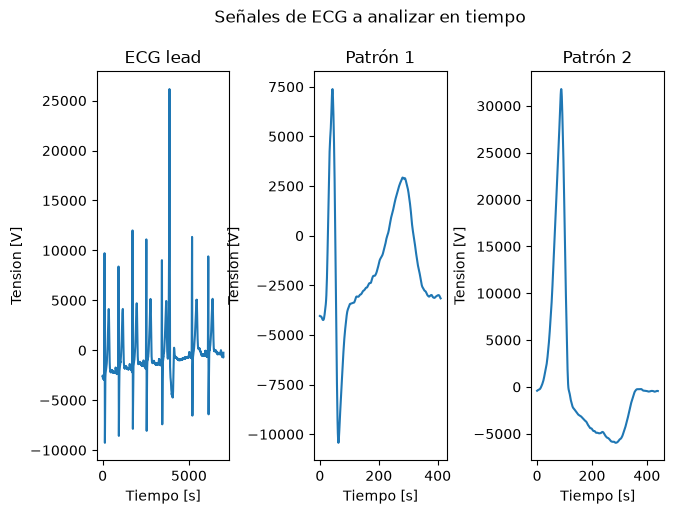

In [11]:
##señales ECG

fs_ecg = 1000 # Hz

##################
## ECG con ruido
##################

# para listar las variables que hay en el archivo
sio.whosmat('ECG_TP4.mat')
mat_struct = sio.loadmat('./ECG_TP4.mat')

ecg_one_lead = mat_struct['ecg_lead']

hb_1_data = mat_struct['heartbeat_pattern1']
hb_2_data = mat_struct['heartbeat_pattern2']

ecg_data_lead = ecg_one_lead[5000:12000,0]
hb_1 = hb_1_data[:,0]
hb_2 = hb_2_data[:,0]


##graficos en tiempo
fig_ecgs_t, ((lead_t, hb_1_t, hb_2_t)) = plt.subplots(1,3)
fig_ecgs_t.suptitle("Señales de ECG a analizar en tiempo",y =1.02)
fig_ecgs_t.tight_layout(w_pad = 3)
fig_ecgs_t.set_size_inches(10,3)

lead_t.set_title("ECG lead")
lead_t.set_xlabel("Tiempo [s]")
lead_t.set_ylabel("Tension [V]")
lead_t.plot(ecg_data_lead)

hb_1_t.set_title("Patrón 1")
hb_1_t.set_xlabel("Tiempo [s]")
hb_1_t.set_ylabel("Tension [V]")
hb_1_t.plot(hb_1)

hb_2_t.set_title("Patrón 2")
hb_2_t.set_xlabel("Tiempo [s]")
hb_2_t.set_ylabel("Tension [V]")
hb_2_t.plot(hb_2)

#### Estimaciones

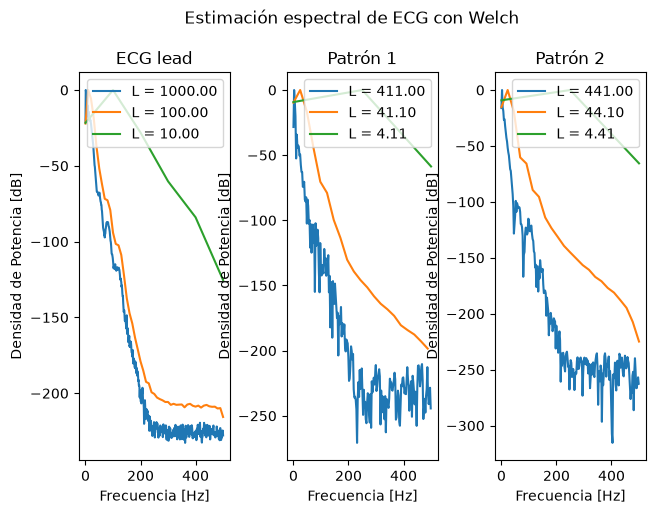

In [12]:
##graficos en frecuencia
fig_ecgs, ((lead_w, hb_1_w, hb_2_w)) = plt.subplots(1,3)
fig_ecgs.suptitle("Estimación espectral de ECG con Welch",y =1.02)
fig_ecgs.tight_layout(w_pad = 1)
fig_ecgs.set_size_inches(10,3)

lead_w.set_title("ECG lead")
lead_w.set_xlabel("Frecuencia [Hz]")
lead_w.set_ylabel("Densidad de Potencia [dB]")

VAR_lead = [0,0,0]
BW_lead = [0,0,0]
plot_db_welch(lead_w, ecg_data_lead, fs_ecg, np.size(ecg_data_lead), 7, 0.95, BW_lead,VAR_lead) 

hb_1_w.set_title("Patrón 1")
hb_1_w.set_xlabel("Frecuencia [Hz]")
hb_1_w.set_ylabel("Densidad de Potencia [dB]")

VAR_hb1 = [0,0,0]
BW_hb1 = [0,0,0]
plot_db_welch(hb_1_w, hb_1, fs_ecg, np.size(hb_1), 1, 0.95, BW_hb1,VAR_hb1)

hb_2_w.set_title("Patrón 2")
hb_2_w.set_xlabel("Frecuencia [Hz]")
hb_2_w.set_ylabel("Densidad de Potencia [dB]")

VAR_hb2 = [0,0,0]
BW_hb2 = [0,0,0]
plot_db_welch(hb_2_w, hb_2, fs_ecg, np.size(hb_2), 1, 0.95, BW_hb2,VAR_hb2)


### PPGs

#### Señal y estimación

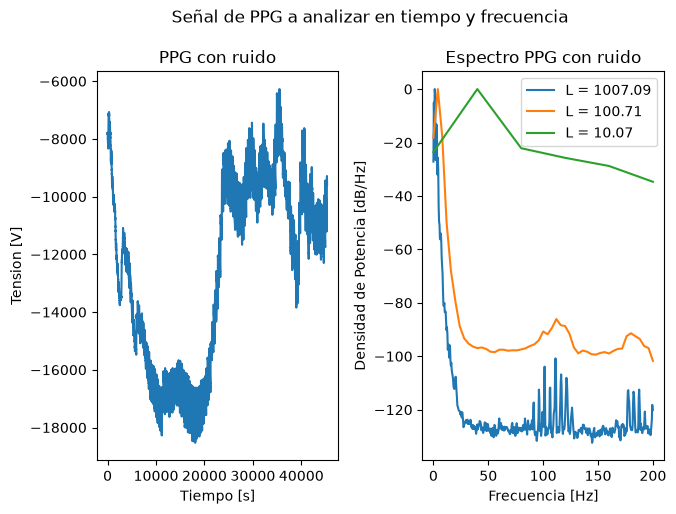

In [16]:
fs_ppg = 400 # Hz

ppg = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)  # Omitir la cabecera si existe

fig_ppgs, ((ppg_t, ppg_w)) = plt.subplots(1,2)
fig_ppgs.suptitle("Señal de PPG a analizar en tiempo y frecuencia",y =1.02)
fig_ppgs.tight_layout(w_pad = 3)
fig_ppgs.set_size_inches(10,3)

ppg_t.set_title("PPG con ruido")
ppg_t.set_xlabel("Tiempo [s]")
ppg_t.set_ylabel("Tension [V]")
ppg_t.plot(ppg)

ppg_w.set_title("Espectro PPG con ruido")
ppg_w.set_xlabel("Frecuencia [Hz]")
ppg_w.set_ylabel("Densidad de Potencia [dB/Hz]")

VAR_ppg = [0,0,0]
BW_ppg = [0,0,0]
plot_db_welch(ppg_w, ppg, fs_ppg, np.size(ppg), 45, 0.95, BW_ppg,VAR_ppg)

#### Estimaciones

## Conclusiones